In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob 
import os

In [2]:
# import re
# df_list = []
# file_paths = sorted(glob.glob("data/california/CRMLSSold*.csv"))
# for file in file_paths:
#     # Extract the 6-digit date string (e.g., '202401') from the filename using regex
#     filename = os.path.basename(file)
#     match = re.search(r"CRMLSSold(\d{4})(\d{2})", filename)

#     if match:
#         year = int(match.group(1))
#         month = int(match.group(2))
#     else:
#         # Fallback if filename structure varies slightly
#         year = None
#         month = None

#     # Read the individual CSV
#     temp_df = pd.read_csv(file)

#     # Inject the engineered time features into this specific batch of data
#     temp_df["Year"] = year
#     temp_df["Month"] = month
#     # Useful as a string format (e.g., "2024-01") for plotting chronological trends later
#     temp_df["YearMonth"] = f"{year}-{month:02d}" if year else None

#     df_list.append(temp_df)

# # 2. Concatenate everything together
# df = pd.concat(df_list, axis=0, ignore_index=True)


In [3]:
# df.to_csv('data/stacked_data.csv', index=False)

In [4]:
df = pd.read_csv('data/stacked_data.csv')

C:\Users\CiciA\AppData\Local\Temp\ipykernel_12968\1822547414.py:1: DtypeWarning: Columns (2,45,78,79,83,84) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data/stacked_data.csv')


1. df general gauge

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 794271 entries, 0 to 794270
Data columns (total 85 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   Flooring                      465886 non-null  object 
 1   ViewYN                        707277 non-null  object 
 2   WaterfrontYN                  434 non-null     object 
 3   BasementYN                    13172 non-null   object 
 4   PoolPrivateYN                 690017 non-null  object 
 5   OriginalListPrice             791935 non-null  float64
 6   ListingKey                    794271 non-null  int64  
 7   ListAgentEmail                792478 non-null  object 
 8   CloseDate                     794271 non-null  object 
 9   ClosePrice                    794263 non-null  float64
 10  ListAgentFirstName            789394 non-null  object 
 11  ListAgentLastName             794180 non-null  object 
 12  Latitude                      793455 non-nul

In [6]:
df.columns

Index(['Flooring', 'ViewYN', 'WaterfrontYN', 'BasementYN', 'PoolPrivateYN',
       'OriginalListPrice', 'ListingKey', 'ListAgentEmail', 'CloseDate',
       'ClosePrice', 'ListAgentFirstName', 'ListAgentLastName', 'Latitude',
       'Longitude', 'UnparsedAddress', 'PropertyType', 'LivingArea',
       'ListPrice', 'DaysOnMarket', 'ListOfficeName', 'BuyerOfficeName',
       'CoListOfficeName', 'ListAgentFullName', 'CoListAgentFirstName',
       'CoListAgentLastName', 'BuyerAgentMlsId', 'BuyerAgentFirstName',
       'BuyerAgentLastName', 'FireplacesTotal', 'AssociationFeeFrequency',
       'AboveGradeFinishedArea', 'ListingKeyNumeric', 'MLSAreaMajor',
       'TaxAnnualAmount', 'CountyOrParish', 'MlsStatus', 'ElementarySchool',
       'AttachedGarageYN', 'ParkingTotal', 'BuilderName', 'PropertySubType',
       'LotSizeAcres', 'SubdivisionName', 'BuyerOfficeAOR', 'YearBuilt',
       'BuyerAgencyCompensationType', 'StreetNumberNumeric', 'ListingId',
       'BathroomsTotalInteger', 'City', 'Bu

2. summary table- missing_pct of each column

In [7]:
summary = pd.DataFrame({
    "dtype": df.dtypes,
    "missing": df.isnull().sum(),
    "missing_pct": df.isnull().mean()*100,
    "unique": df.nunique()
})
\
# summary = summary[summary["missing"] > 0]
summary.sort_values(
    "missing_pct",
    ascending=False
)

,dtype,missing,missing_pct,unique
MiddleOrJuniorSchoolDistrict,float64,794271,100.0,0
ElementarySchoolDistrict,float64,794271,100.0,0
CoveredSpaces,float64,794271,100.0,0
AboveGradeFinishedArea,float64,794271,100.0,0
FireplacesTotal,float64,794271,100.0,0
...,...,...,...,...
ListingKey,int64,0,0.0,793625
PropertyType,object,0,0.0,9
Year,int64,0,0.0,4
YearMonth,object,0,0.0,30


In [8]:
#description = ['total number of garage and carport spaces', 'total number of fireplaces', 'name of the school, 'name of the elementary school', 'finished area at or above surface of the ground', 'whether on the waterfront', 'tax base year', 'type of business sold', 'unfinished area below grade']

In [9]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

display(
    summary.sort_values("missing_pct", ascending=False)
)

,dtype,missing,missing_pct,unique
MiddleOrJuniorSchoolDistrict,float64,794271,100.000000,0
ElementarySchoolDistrict,float64,794271,100.000000,0
CoveredSpaces,float64,794271,100.000000,0
AboveGradeFinishedArea,float64,794271,100.000000,0
FireplacesTotal,float64,794271,100.000000,0
WaterfrontYN,object,793837,99.945359,1
TaxYear,float64,793773,99.937301,17
BusinessType,object,792013,99.715714,995
BelowGradeFinishedArea,float64,790928,99.579111,200
TaxAnnualAmount,float64,790912,99.577096,2288


3. missingness plot
- histogram 
- heatmap (misno)

<Axes: xlabel='missing_pct', ylabel='Percent'>

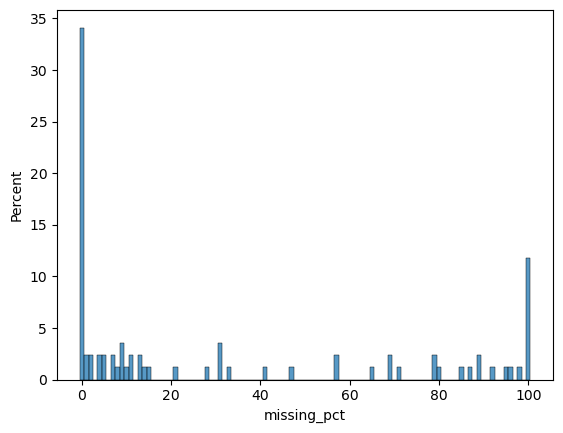

In [10]:
sns.histplot(data=summary, x='missing_pct', stat='percent', discrete=True)

4. columns dropping/imputation

In [11]:
drop_cols = summary[summary["missing_pct"] > 50].index
df_dropped = df.drop(columns=drop_cols)

numeric_cols = df_dropped.select_dtypes(
    include=["number"]
).columns

categorical_cols = df_dropped.select_dtypes(
    include=["object", "category"]
).columns


In [12]:
numeric_cols = df_dropped.select_dtypes(
    include=["number"]
).columns

categorical_cols = df_dropped.select_dtypes(
    include=["object", "category"]
).columns

In [13]:
# numeric imputation
for col in numeric_cols:
    if df_dropped[col].isna().any():
        df_dropped[col] = df_dropped[col].fillna(df_dropped[col].median())


# note if tree model: use -999

In [14]:
# categorical imputation
for col in categorical_cols:
    if df_dropped[col].isna().any():
        df_dropped[col] = df_dropped[col].fillna("Unknown")

In [ ]:
df_dropped.to_csv("data/df_cleaned.csv", index=False)

5.0